[2026-08-04 23:08:55] [info     ] 计算因子，区间：2022-01-01 00:00:00 ~ 2025-12-31 23:59:59
[2026-08-04 23:09:16] [info     ] 读取因子库，区间：2022-01-01 00:00:00 ~ 2025-12-31 23:59:59
[2026-08-04 23:09:17] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-08-04 23:09:30] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-08-04 23:09:31] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-08-04 23:09:32] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2022-01-04 至 2024-12-31
[2026-08-04 23:09:32] [info     ] ========== 数据检查 ==========
[2026-08-04 23:09:32] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg

时段,IC
2024-01-15~2024-02-08,-0.0199
2024-09-24~2024-10-08,-0.0697

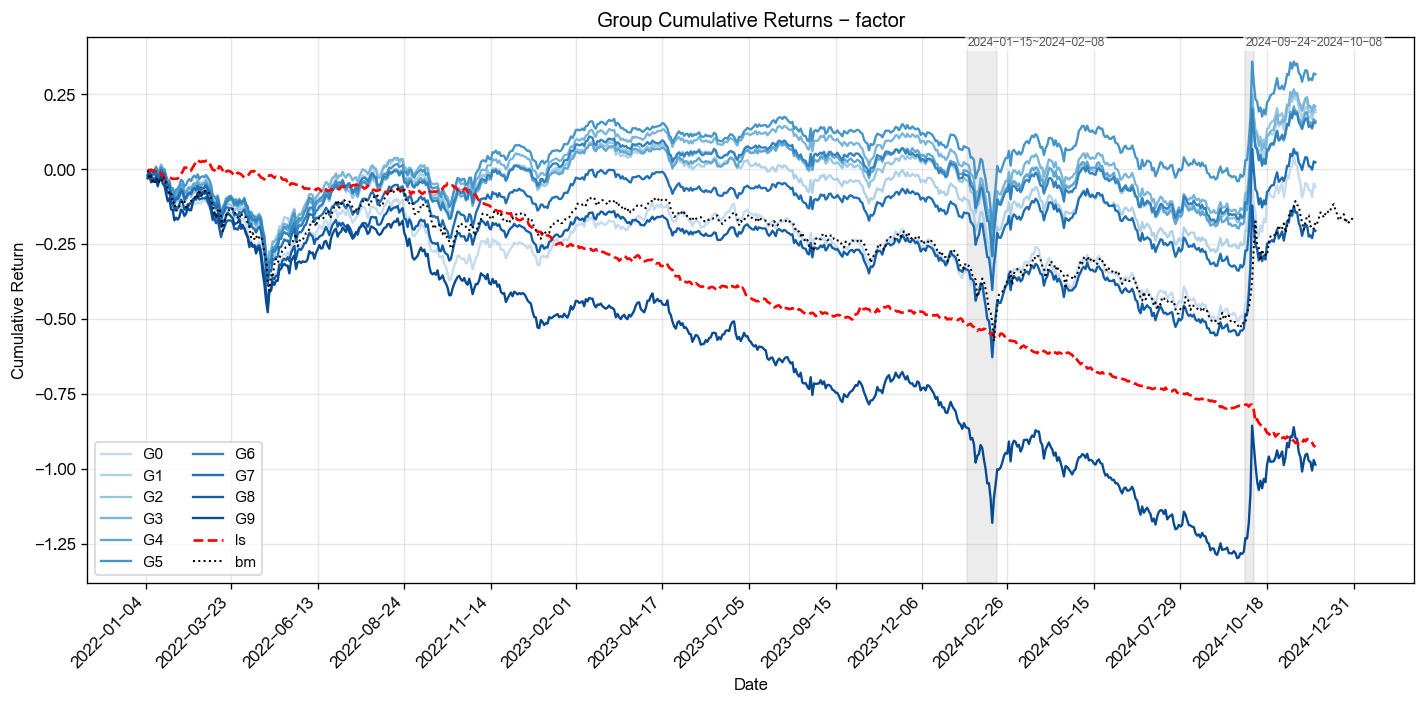
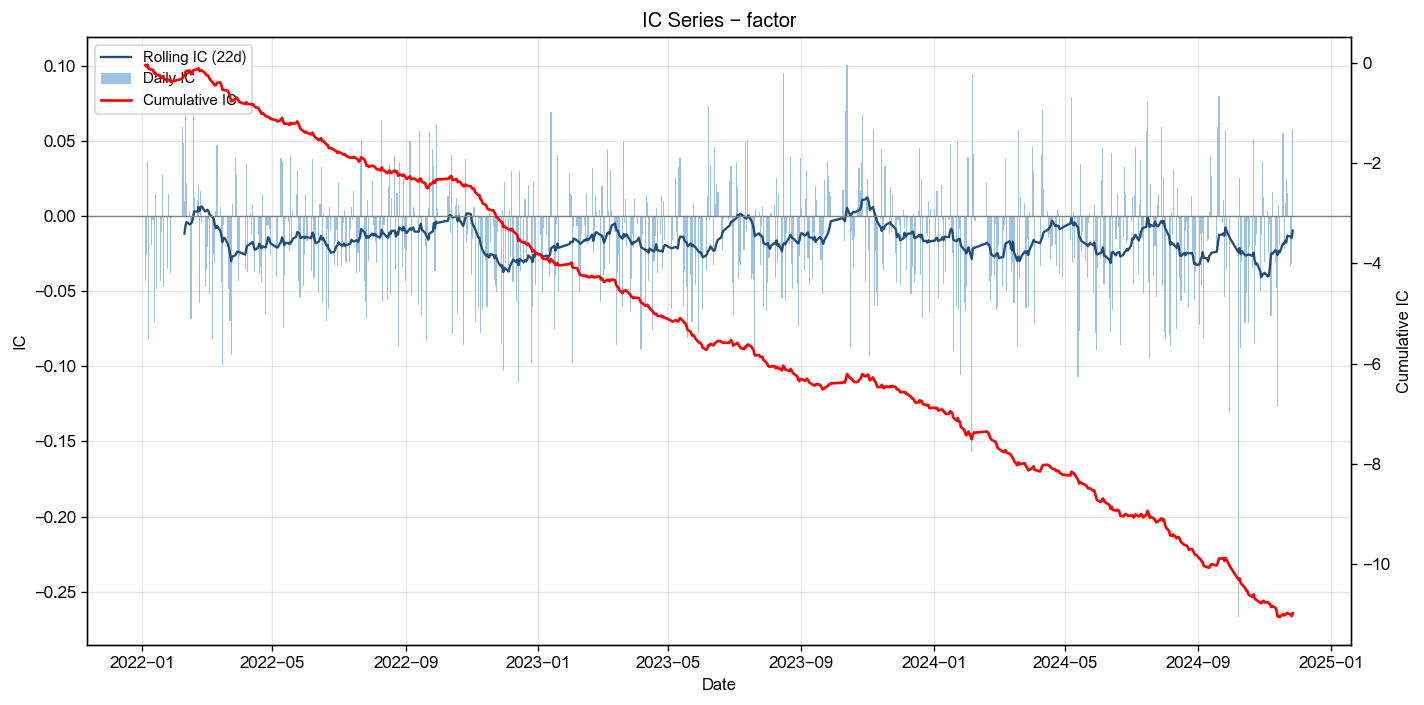
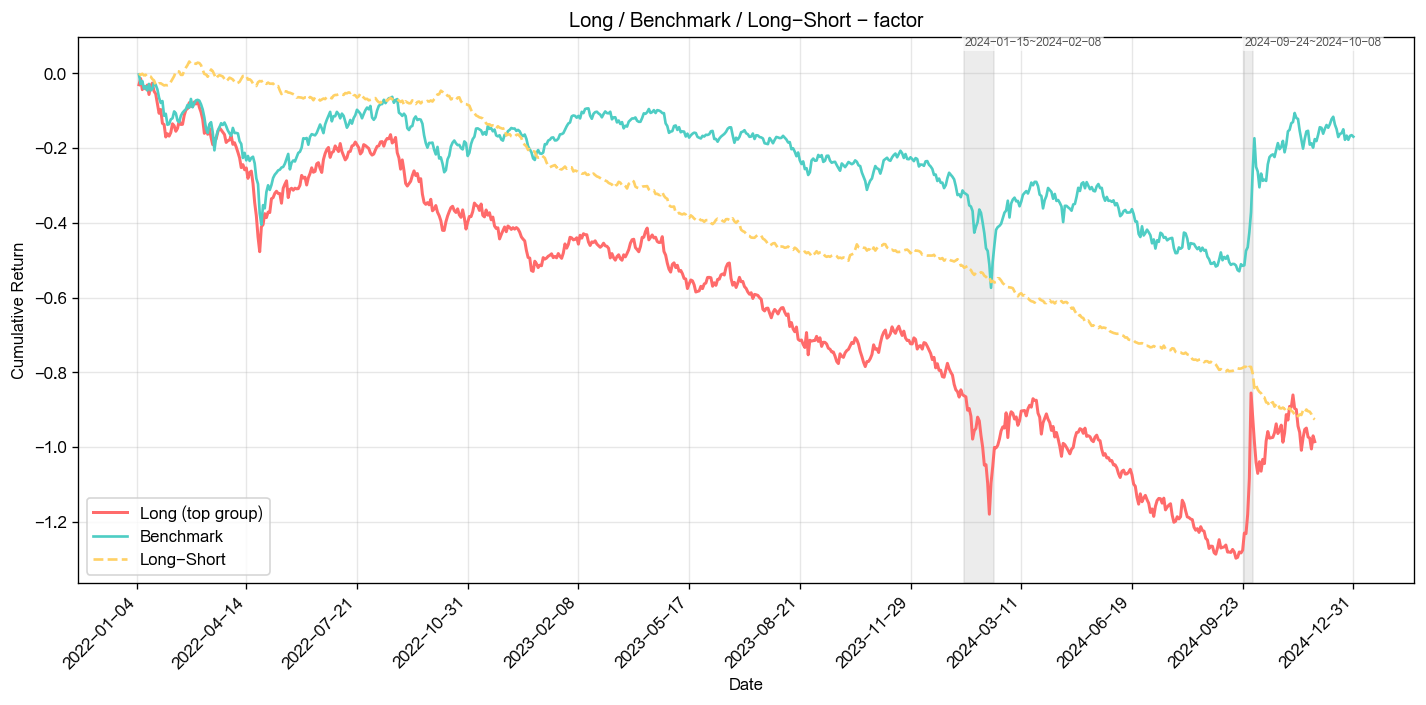
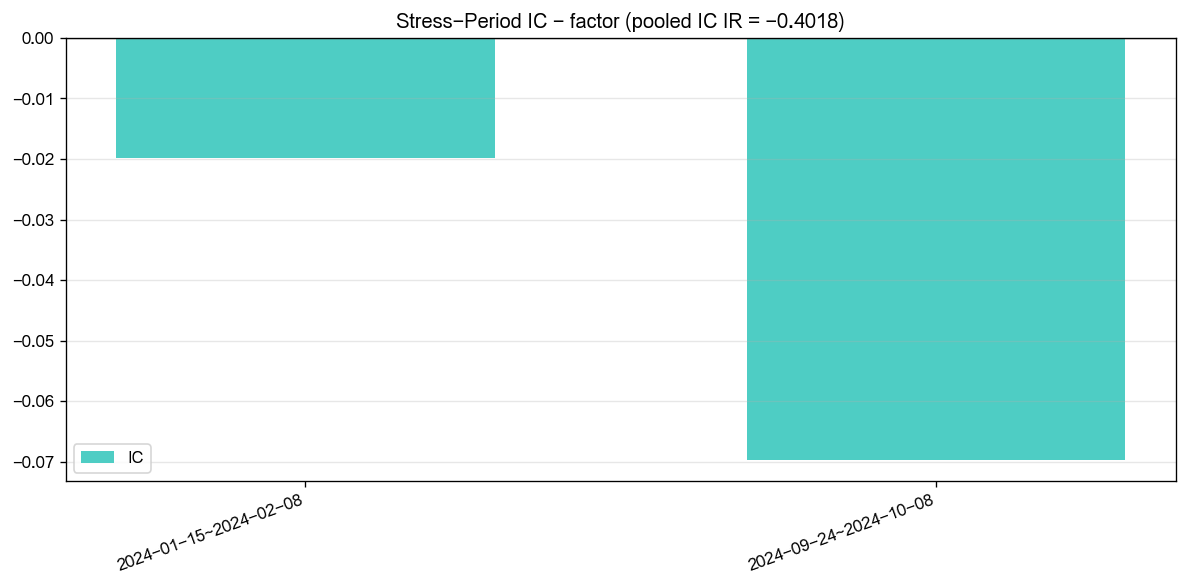
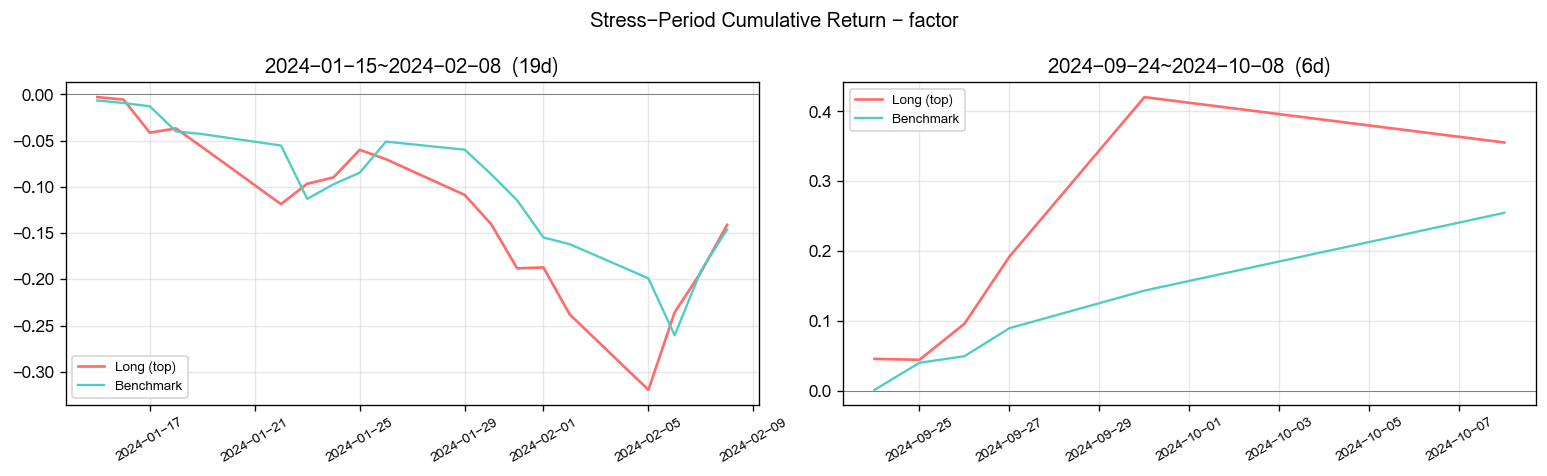

[2026-08-04 23:10:35] [info     ] ========== 因子池回归 ==========
[2026-08-04 23:10:36] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1571 rows=1105750 start_date=2022-01-04
[2026-08-04 23:10:38] [info     ] 获取收益率数据, 耗时: 3.3922 秒
[2026-08-04 23:10:39] [info     ] 滚动 Elastic Net 拟合, 耗时: 1.3799 秒
[2026-08-04 23:10:39] [info     ] 统计 回归结果, 耗时: 0.0558 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,factor,2.7788,0.0246,0.0088,1.0000
2,volatility_5,1.5470,0.0158,0.0102,1.0000
3,cci_14,1.3973,0.0252,0.0181,1.0000
4,roe_avg_ttm,1.3763,0.0094,0.0068,0.8529
5,beta_000300SH_22,1.3684,0.0183,0.0134,0.9706
6,rsi_12,1.3330,0.0326,0.0244,0.9412
7,volume,1.3283,0.0156,0.0118,0.9706
8,bias_20,1.3204,0.0277,0.0210,0.9412
9,momentum_5,1.3195,0.0173,0.0131,0.9706
10,net_active_buy_amount_main,1.3100,0.0184,0.0140,0.9412

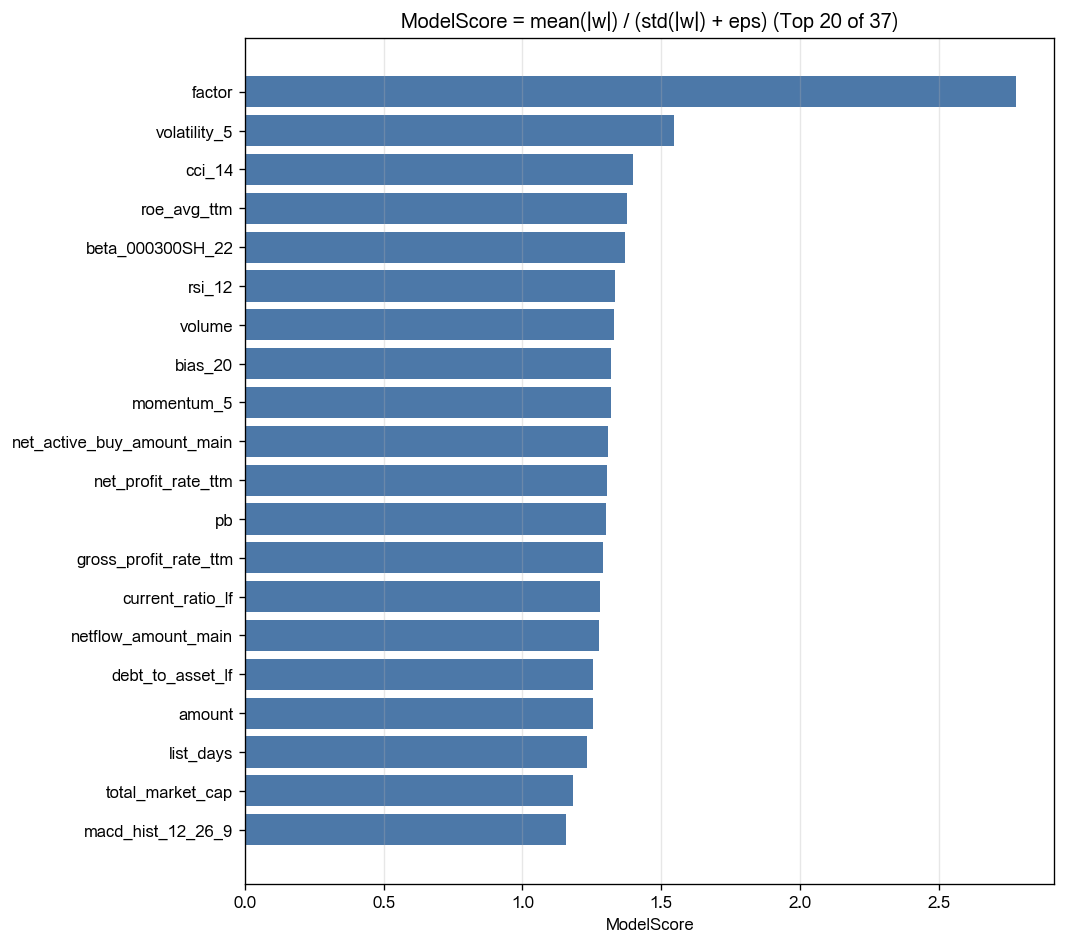
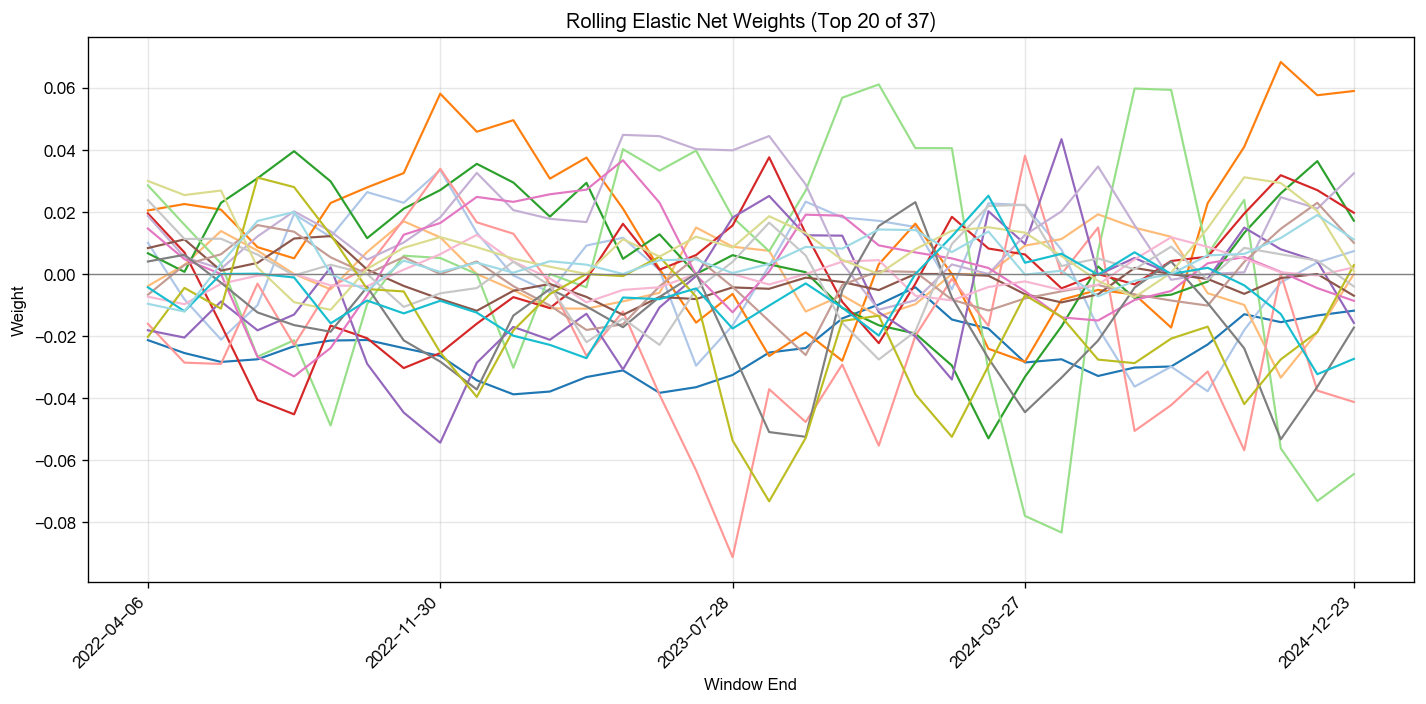
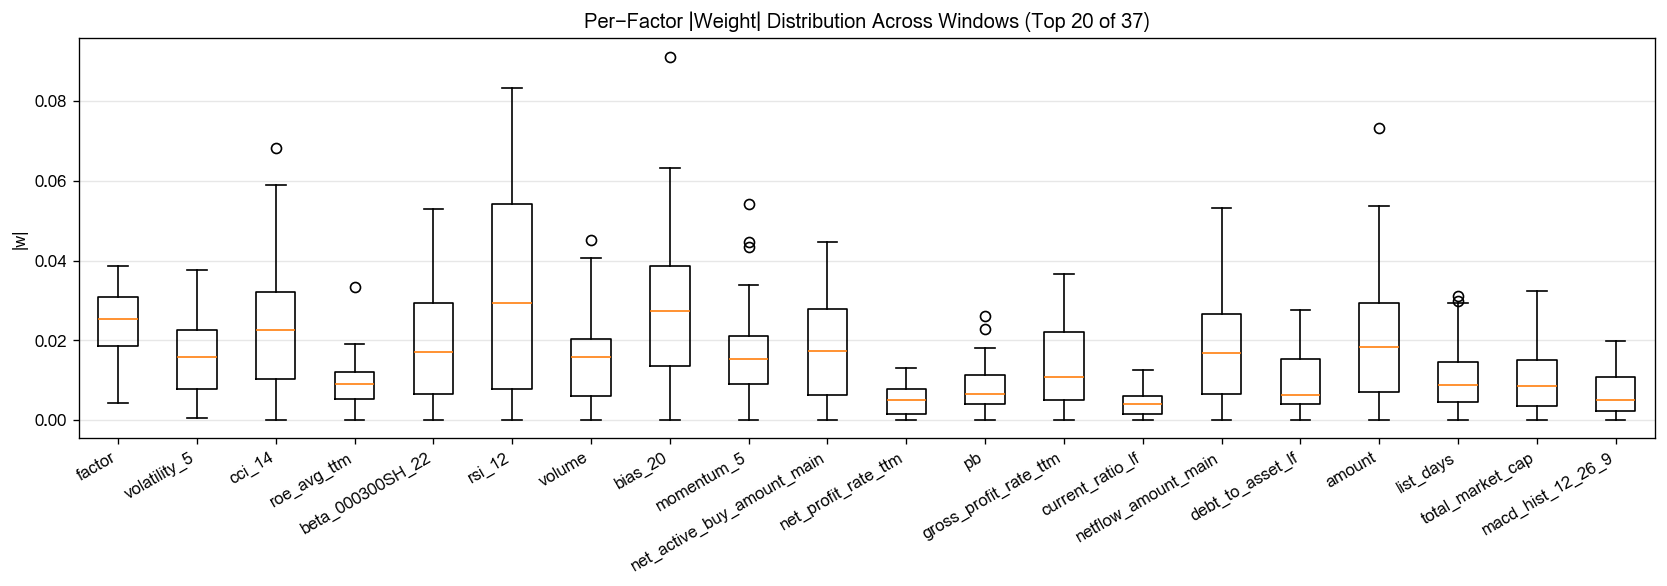
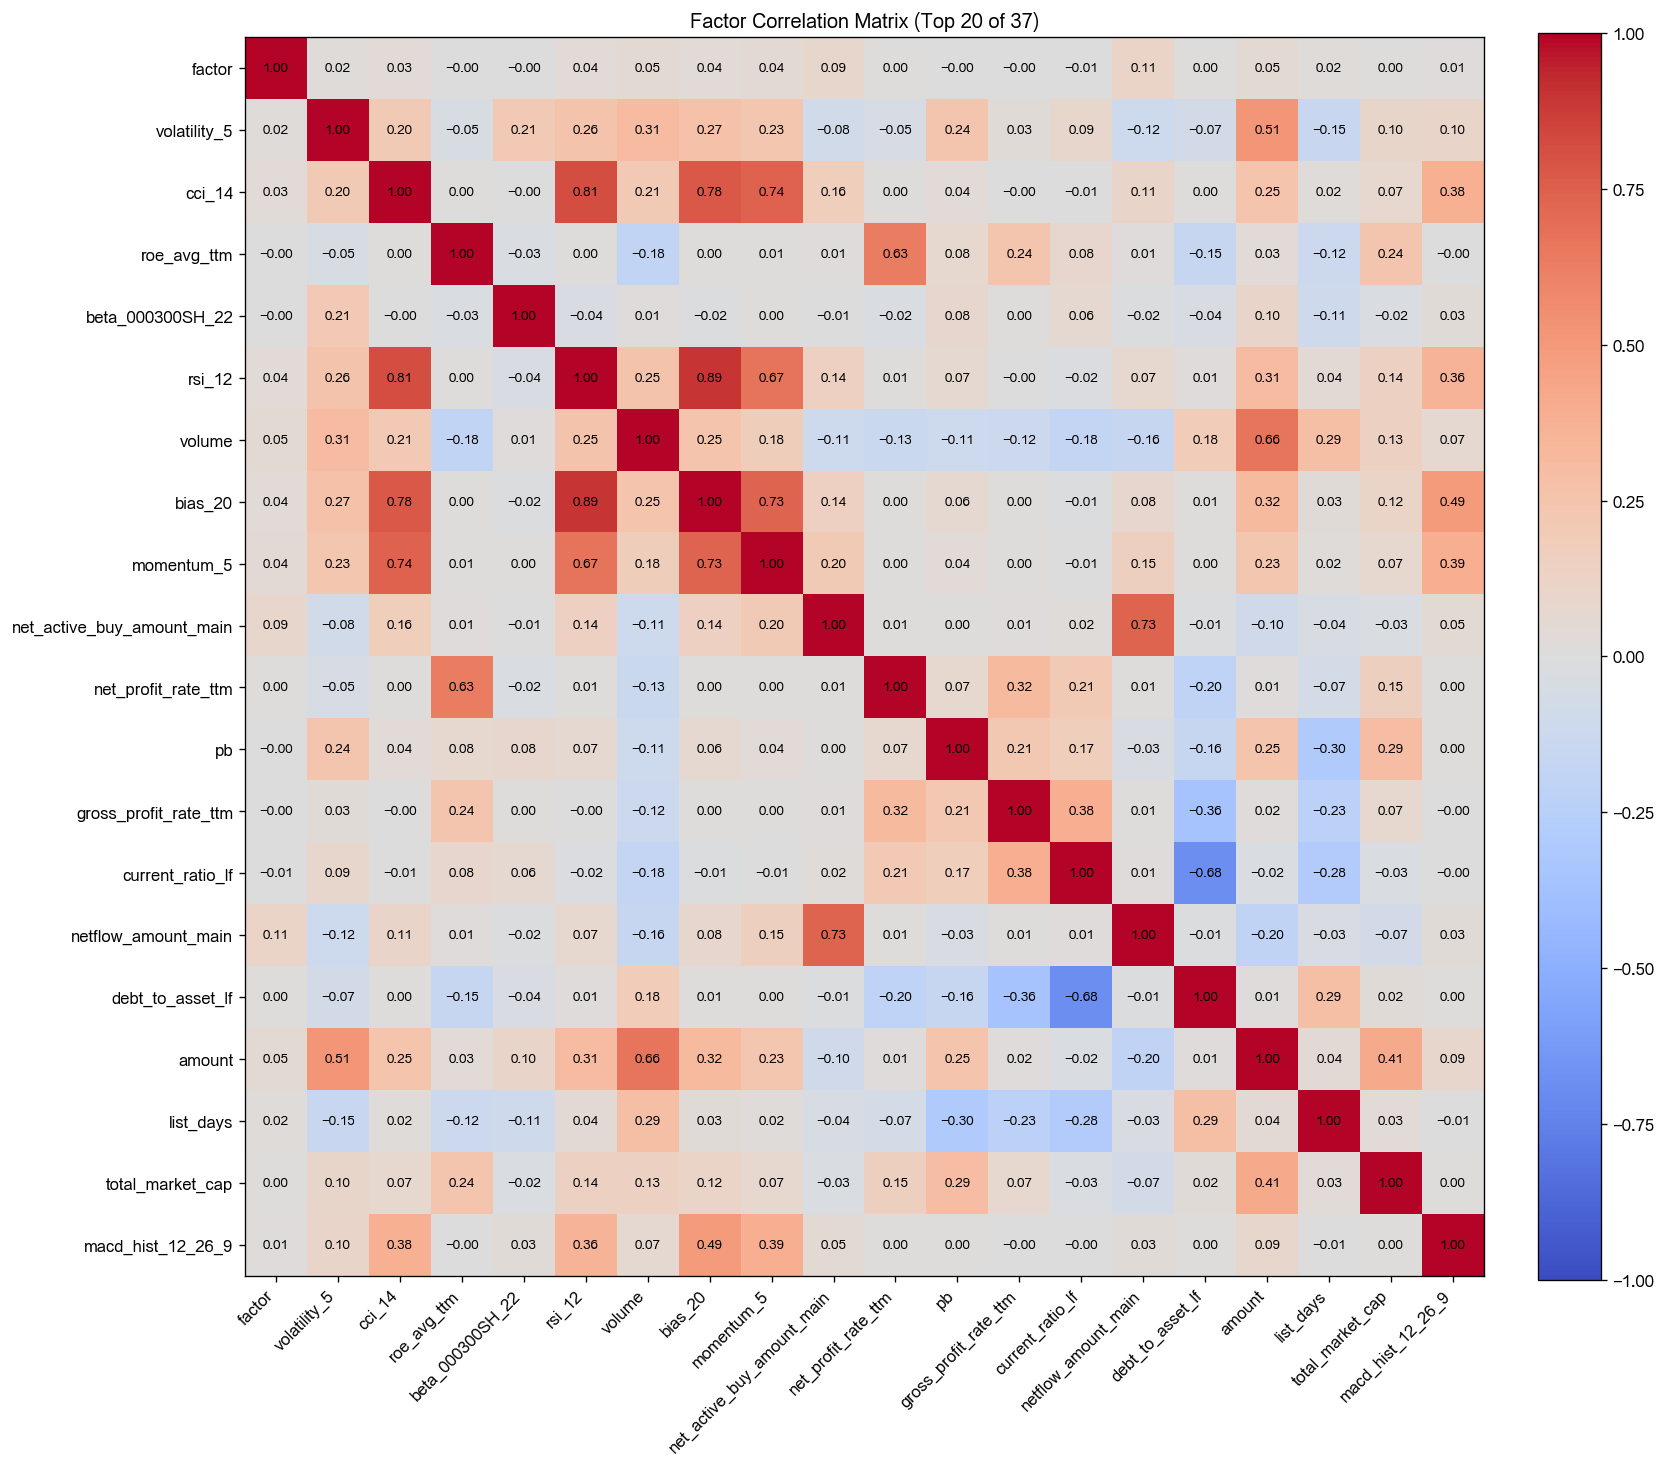

[2026-08-04 23:10:45] [warning  ] 返回的Outputs实例(size=106989302) 大于 64K, 将不会被缓存
[2026-08-04 23:10:45] [info     ] bigalpha_eval.v4 运行完成 [75.128s].


In [1]:
def main(datasources, start_date, end_date):
    """
    因子构建主函数

    评测时平台会自动替换 datasources / start_date / end_date 三个入参并调用本函数

    因子逻辑:
        TailRatio = 尾盘 14:52-14:57 volume / 全天 volume
        Direction = sign(尾盘 close - 尾盘 open)
        factor = TailRatio * 全天 amount * Direction
        （date 为 bar 结束时刻；尾盘取 hour=14 且 minute∈[52,57]）

    参数:
        datasources (dict): 数据源表名映射 {逻辑名: 物理表名}
                            当前可用逻辑名:
                                "bar1m"     -> 分钟 K 线表
                                "financial" -> 财务数据表
        start_date (str): 开始时间
        end_date (str):   结束时间

    返回:
        pd.DataFrame: 因子数据，须包含三列 ['date', 'instrument', 'factor']，且不含 inf
    """
    import pandas as pd
    import dai

    bar1m = datasources["bar1m"]

    # ===== 编写因子 SQL =====
    sql = f"""
    WITH cte_bar1m AS (
        SELECT
            date,
            instrument,
            volume,
            amount,
            open,
            close,
            strftime(date, '%Y-%m-%d') AS trading_day,
            CASE
                WHEN hour(date) = 14 AND minute(date) BETWEEN 52 AND 57
                THEN 1
                ELSE 0
            END AS is_tail,
            CASE
                WHEN hour(date) = 14 AND minute(date) BETWEEN 52 AND 57
                THEN volume
                ELSE 0
            END AS tail_volume
        FROM {bar1m}
        WHERE volume IS NOT NULL AND volume >= 0
          AND amount IS NOT NULL AND amount >= 0
    ),
    cte_daily AS (
        SELECT
            trading_day,
            instrument,
            SUM(tail_volume) AS tail_volume_sum,
            SUM(volume) AS day_volume_sum,
            SUM(amount) AS day_amount_sum,
            -- 尾盘第一根 open、最后一根 close（近似逐笔首末价）
            arg_min(CASE WHEN is_tail = 1 THEN open END, date) AS tail_open,
            arg_max(CASE WHEN is_tail = 1 THEN close END, date) AS tail_close,
            CASE
                WHEN SUM(volume) > 0
                 AND arg_min(CASE WHEN is_tail = 1 THEN open END, date) IS NOT NULL
                 AND arg_max(CASE WHEN is_tail = 1 THEN close END, date) IS NOT NULL
                THEN (SUM(tail_volume) * 1.0 / SUM(volume)) * SUM(amount)
                     * CASE
                           WHEN arg_max(CASE WHEN is_tail = 1 THEN close END, date)
                              > arg_min(CASE WHEN is_tail = 1 THEN open END, date)
                           THEN 1.0
                           WHEN arg_max(CASE WHEN is_tail = 1 THEN close END, date)
                              < arg_min(CASE WHEN is_tail = 1 THEN open END, date)
                           THEN -1.0
                           ELSE 0.0
                       END
                ELSE NULL
            END AS factor
        FROM cte_bar1m
        GROUP BY instrument, trading_day
    )
    SELECT
        CAST(trading_day AS DATETIME) AS date,
        instrument,
        factor
    FROM cte_daily
    WHERE factor IS NOT NULL
      AND isfinite(factor)
    """

    # ===== 调用 dai 计算因子 =====
    df = dai.query(sql, filters={'date': [start_date, end_date]}, compression=True).df()

    # ===== 对齐股票池（中证 1000 成分）=====
    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={'date': [start_date, end_date]},
    ).df()
    df = pd.merge(df, stk_pool, how='inner', on=['date', 'instrument'])

    return df


if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    datasources = {'bar1m': 'bigalpha_2026_stock_bar1m'}
    start_date = '2022-01-01 00:00:00'
    end_date = '2025-12-31 23:59:59'

    logger.info(f"计算因子，区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )